# 05e — E2.2 Cross-Dataset Evaluation on Celeb-DF v2

Evaluate the clean-rerun E2.2 checkpoint—ImageNet EfficientNet-B0 fully fine-tuned on RetinaFace crops from FaceForensics++—on the fixed Celeb-DF v2 face-crop pilot without retraining, adaptation, or threshold tuning.

Compare E2.2 directly with E2.1. The architecture, full fine-tuning strategy, ImageNet preprocessing, external videos, frame sampling, aggregation, and threshold remain fixed; the intended input change is full frame versus matched RetinaFace crop.


## 1. Run controls


In [1]:
INSTALL_DEPENDENCIES = False
RUN_EVALUATION = True
ALLOW_RESULT_OVERWRITE = False

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 32
NUM_WORKERS = 0

assert DECISION_THRESHOLD == 0.5
print("E2.2 Celeb-DF evaluation enabled:", RUN_EVALUATION)
print("Allow result overwrite:", ALLOW_RESULT_OVERWRITE)
print("Decision threshold:", DECISION_THRESHOLD)


E2.2 Celeb-DF evaluation enabled: True
Allow result overwrite: False
Decision threshold: 0.5


## 2. Environment and canonical paths


In [2]:
import json
import random
import subprocess
import sys
from pathlib import Path

if INSTALL_DEPENDENCIES:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision", "pandas", "matplotlib", "scikit-learn",
    ])

from google.colab import drive
drive.mount("/content/drive")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
PILOT_FACES_DIR = BASE_PATH / "celebdf_v2" / "pilot_faces"
MANIFEST_PATH = BASE_PATH / "celebdf_v2" / "celebdf_pilot_manifest.json"
CHECKPOINT_PATH = BASE_PATH / "saved_models" / "efficientnet_b0_face_finetuned.pth"
RESULTS_DIR = BASE_PATH / "results" / "cross_dataset"
PLOTS_DIR = BASE_PATH / "plots" / "cross_dataset"

RESULTS_JSON = RESULTS_DIR / "e22_celebdf_results.json"
FRAME_CSV = RESULTS_DIR / "e22_celebdf_frame_predictions.csv"
VIDEO_CSV = RESULTS_DIR / "e22_celebdf_video_predictions.csv"
FRAME_CM = PLOTS_DIR / "e22_celebdf_frame_confusion_matrix.png"
FRAME_ROC = PLOTS_DIR / "e22_celebdf_frame_roc_curve.png"
VIDEO_CM = PLOTS_DIR / "e22_celebdf_video_confusion_matrix.png"
VIDEO_ROC = PLOTS_DIR / "e22_celebdf_video_roc_curve.png"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for path, label in [
    (PILOT_FACES_DIR / "real", "Celeb-DF real face crops"),
    (PILOT_FACES_DIR / "fake", "Celeb-DF fake face crops"),
    (MANIFEST_PATH, "Celeb-DF pilot manifest"),
    (CHECKPOINT_PATH, "E2.2 checkpoint"),
]:
    if not path.exists(): raise FileNotFoundError(f"{label} not found: {path}")

if RUN_EVALUATION and not ALLOW_RESULT_OVERWRITE:
    existing=[p for p in [RESULTS_JSON,FRAME_CSV,VIDEO_CSV,FRAME_CM,FRAME_ROC,VIDEO_CM,VIDEO_ROC] if p.exists()]
    if existing:
        raise FileExistsError(
            "E2.2 external outputs already exist. Set ALLOW_RESULT_OVERWRITE = True only "
            f"when intentional: {existing}"
        )

print("Device:", DEVICE)
print("Test data:", PILOT_FACES_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Manifest:", MANIFEST_PATH)


Mounted at /content/drive
Device: cuda
Test data: /content/drive/MyDrive/deepfake_project/celebdf_v2/pilot_faces
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_face_finetuned.pth
Manifest: /content/drive/MyDrive/deepfake_project/celebdf_v2/celebdf_pilot_manifest.json


## 3. Validate the fixed face-crop pilot

Canonical evaluation labels are `real=0`, `fake=1`. E2.2 was trained with ImageFolder ordering `fake=0`, `real=1`, so checkpoint output index 0 is converted into the canonical fake probability.


In [3]:
VALID_EXTENSIONS={".jpg",".jpeg",".png",".bmp",".webp"}
CANONICAL_CLASS_TO_LABEL={"real":0,"fake":1}
LABEL_TO_CLASS={0:"real",1:"fake"}
MODEL_FAKE_INDEX=0

def images_in(folder):
    return sorted(p for p in Path(folder).iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS)

def video_id(path):
    if "__frame_" not in path.stem: raise ValueError(f"Unexpected filename: {path.name}")
    return path.stem.split("__frame_",1)[0]

with MANIFEST_PATH.open("r",encoding="utf-8") as handle: manifest=json.load(handle)
assert len(manifest["real_videos"])==20 and len(manifest["fake_videos"])==20
assert manifest["frames_per_video"]==10

audit=[]
for class_name in ("real","fake"):
    paths=images_in(PILOT_FACES_DIR/class_name)
    counts={}
    for p in paths: counts[video_id(p)]=counts.get(video_id(p),0)+1
    audit.append({"class":class_name,"frames":len(paths),"videos":len(counts),"minimum_per_video":min(counts.values()),"maximum_per_video":max(counts.values())})
    assert len(paths)==200 and len(counts)==20 and set(counts.values())=={10}
display(pd.DataFrame(audit))
print("PASS: fixed Celeb-DF face-crop pilot contains 400 crops from 40 videos.")
print("Model fake-output index:",MODEL_FAKE_INDEX)


,class,frames,videos,minimum_per_video,maximum_per_video
0,real,200,20,10,10
1,fake,200,20,10,10


PASS: fixed Celeb-DF face-crop pilot contains 400 crops from 40 videos.
Model fake-output index: 0


## 4. E2.2 preprocessing and evaluation dataset


In [4]:
weights = EfficientNet_B0_Weights.DEFAULT
e22_preprocess = weights.transforms()

class CelebDFFaceCropDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        self.transform = transform
        for class_name, label in CANONICAL_CLASS_TO_LABEL.items():
            for path in images_in(Path(root) / class_name):
                self.samples.append((path, label, class_name, video_id(path)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label, class_name, source_video = self.samples[index]
        image = self.transform(Image.open(path).convert("RGB"))
        return image, label, class_name, source_video, path.name, str(path)

dataset = CelebDFFaceCropDataset(PILOT_FACES_DIR, e22_preprocess)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
assert len(dataset) == 400
batch = next(iter(loader))[0]
assert tuple(batch.shape[1:]) == (3, 224, 224)
print("Images:", len(dataset))
print("Input batch shape:", batch.shape)


Images: 400
Input batch shape: torch.Size([32, 3, 224, 224])


## 5. Rebuild and load the E2.2 EfficientNet-B0


In [5]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state = checkpoint["state_dict"]
    else:
        state = checkpoint
    if not isinstance(state, dict):
        raise TypeError("Checkpoint does not contain a state dictionary.")
    return {key.removeprefix("module."): value for key, value in state.items()}

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(extract_state_dict(checkpoint), strict=True)
model = model.to(DEVICE)
model.eval()
print("E2.2 checkpoint loaded successfully.")


E2.2 checkpoint loaded successfully.


## 6. Shared metric and plotting helpers


In [8]:
def metric_bundle(labels,predictions,probabilities):
    labels=np.asarray(labels); predictions=np.asarray(predictions); probabilities=np.asarray(probabilities)
    return {
        "accuracy":float(accuracy_score(labels,predictions)),
        "macro_precision":float(precision_score(labels,predictions,average="macro",zero_division=0)),
        "macro_recall":float(recall_score(labels,predictions,average="macro",zero_division=0)),
        "macro_f1":float(f1_score(labels,predictions,average="macro",zero_division=0)),
        "fake_precision":float(precision_score(labels,predictions,pos_label=1,zero_division=0)),
        "fake_recall":float(recall_score(labels,predictions,pos_label=1,zero_division=0)),
        "fake_f1":float(f1_score(labels,predictions,pos_label=1,zero_division=0)),
        "roc_auc":float(roc_auc_score(labels,probabilities)),
        "confusion_matrix":confusion_matrix(labels,predictions,labels=[0,1]).tolist(),
    }

def save_plots(level,labels,probabilities,metrics,cm_path,roc_path):
    ConfusionMatrixDisplay(np.asarray(metrics["confusion_matrix"]),display_labels=["real","fake"]).plot(values_format="d")
    plt.title(f"E2.2 on Celeb-DF v2 — {level.title()} Confusion Matrix")
    plt.savefig(cm_path,bbox_inches="tight",dpi=300); plt.show(); plt.close()
    fpr,tpr,_=roc_curve(labels,probabilities)
    plt.figure(figsize=(7,6)); plt.plot(fpr,tpr,label=f"AUC = {metrics['roc_auc']:.4f}")
    plt.plot([0,1],[0,1],"--",label="Random classifier"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"E2.2 on Celeb-DF v2 — {level.title()} ROC"); plt.legend(); plt.grid(True)
    plt.savefig(roc_path,bbox_inches="tight",dpi=300); plt.show(); plt.close()


## 7. Run fixed cross-dataset inference


E2.2 — CELEB-DF FRAME-LEVEL RESULTS
Items evaluated : 400
Accuracy         : 59.50%
Macro precision  : 59.55%
Macro recall     : 59.50%
Macro F1-score   : 59.45%
Fake recall      : 56.00%
ROC-AUC          : 0.6234
              precision    recall  f1-score   support

        real     0.5888    0.6300    0.6087       200
        fake     0.6022    0.5600    0.5803       200

    accuracy                         0.5950       400
   macro avg     0.5955    0.5950    0.5945       400
weighted avg     0.5955    0.5950    0.5945       400

Confusion matrix [real, fake]:
[[126  74]
 [ 88 112]]
E2.2 — CELEB-DF VIDEO-LEVEL RESULTS
Items evaluated : 40
Accuracy         : 62.50%
Macro precision  : 62.53%
Macro recall     : 62.50%
Macro F1-score   : 62.48%
Fake recall      : 60.00%
ROC-AUC          : 0.6575
              precision    recall  f1-score   support

        real     0.6190    0.6500    0.6341        20
        fake     0.6316    0.6000    0.6154        20

    accuracy                

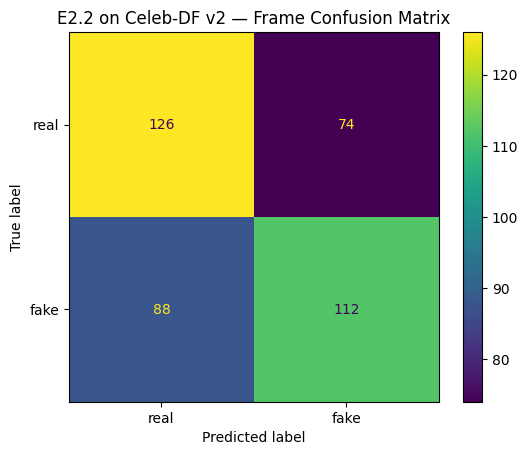

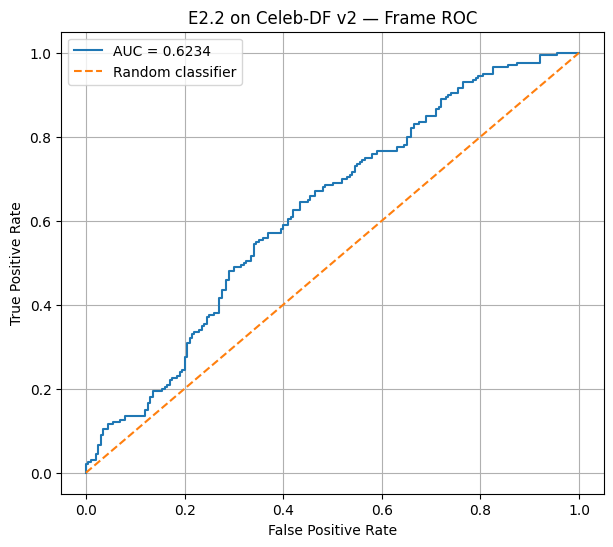

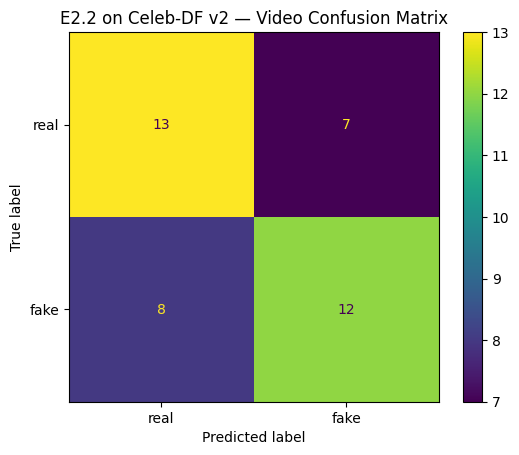

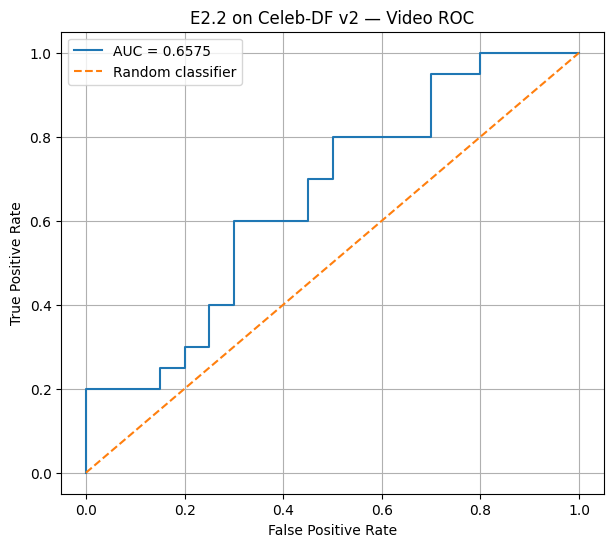

Results saved to: /content/drive/MyDrive/deepfake_project/results/cross_dataset/e22_celebdf_results.json


In [9]:
if RUN_EVALUATION:
    records=[]
    with torch.no_grad():
        for images,labels,class_names,video_ids,filenames,paths in loader:
            probabilities=torch.softmax(model(images.to(DEVICE)),dim=1)[:,MODEL_FAKE_INDEX].cpu().numpy()
            for i,p in enumerate(probabilities):
                predicted=int(p>=DECISION_THRESHOLD); true=int(labels[i])
                records.append({"image_path":paths[i],"filename":filenames[i],"video_id":video_ids[i],"class_name":class_names[i],
                    "true_fake_label":true,"true_class":LABEL_TO_CLASS[true],"predicted_fake_label":predicted,
                    "predicted_class":LABEL_TO_CLASS[predicted],"fake_probability":float(p)})
    frame_df=pd.DataFrame(records)
    assert len(frame_df)==400
    video_df=(frame_df.groupby(["class_name","video_id"],as_index=False)
        .agg(true_fake_label=("true_fake_label","first"),mean_fake_probability=("fake_probability","mean"),number_of_frames=("filename","count")))
    video_df["predicted_fake_label"]=(video_df["mean_fake_probability"]>=DECISION_THRESHOLD).astype(int)
    video_df["true_class"]=video_df["true_fake_label"].map(LABEL_TO_CLASS)
    video_df["predicted_class"]=video_df["predicted_fake_label"].map(LABEL_TO_CLASS)
    assert len(video_df)==40 and video_df["number_of_frames"].eq(10).all()

    frame_metrics=metric_bundle(frame_df.true_fake_label,frame_df.predicted_fake_label,frame_df.fake_probability)
    video_metrics=metric_bundle(video_df.true_fake_label,video_df.predicted_fake_label,video_df.mean_fake_probability)
    frame_report=classification_report(frame_df.true_fake_label,frame_df.predicted_fake_label,labels=[0,1],target_names=["real","fake"],digits=4,zero_division=0)
    video_report=classification_report(video_df.true_fake_label,video_df.predicted_fake_label,labels=[0,1],target_names=["real","fake"],digits=4,zero_division=0)

    for title,count,metrics,report in [("FRAME-LEVEL",len(frame_df),frame_metrics,frame_report),("VIDEO-LEVEL",len(video_df),video_metrics,video_report)]:
        print("="*65); print(f"E2.2 — CELEB-DF {title} RESULTS"); print("="*65)
        print("Items evaluated :",count); print(f"Accuracy         : {metrics['accuracy']*100:.2f}%")
        print(f"Macro precision  : {metrics['macro_precision']*100:.2f}%"); print(f"Macro recall     : {metrics['macro_recall']*100:.2f}%")
        print(f"Macro F1-score   : {metrics['macro_f1']*100:.2f}%"); print(f"Fake recall      : {metrics['fake_recall']*100:.2f}%")
        print(f"ROC-AUC          : {metrics['roc_auc']:.4f}"); print(report); print("Confusion matrix [real, fake]:"); print(np.asarray(metrics["confusion_matrix"]))

    frame_df.to_csv(FRAME_CSV,index=False); video_df.to_csv(VIDEO_CSV,index=False)
    save_plots("frame",frame_df.true_fake_label,frame_df.fake_probability,frame_metrics,FRAME_CM,FRAME_ROC)
    save_plots("video",video_df.true_fake_label,video_df.mean_fake_probability,video_metrics,VIDEO_CM,VIDEO_ROC)
    result={"experiment":"E2.2","training_dataset":"FaceForensics++","external_test_dataset":"Celeb-DF v2 pilot",
        "external_input":"retinaface_crop",
        "preprocessing":"EfficientNet_B0_Weights.DEFAULT.transforms()","evaluation_type":"cross-dataset; no retraining or adaptation","checkpoint":str(CHECKPOINT_PATH),
        "decision_threshold":DECISION_THRESHOLD,"model_fake_output_index":MODEL_FAKE_INDEX,
        "video_aggregation":"mean fake probability across 10 frames","frames_evaluated":len(frame_df),"videos_evaluated":len(video_df),
        "frame_level":frame_metrics,"video_level":video_metrics}
    with RESULTS_JSON.open("w",encoding="utf-8") as handle: json.dump(result,handle,indent=2)
    print("Results saved to:",RESULTS_JSON)
else:
    print("Evaluation skipped because RUN_EVALUATION = False.")


## Methodological safeguards

- E2.2 receives no Celeb-DF training, adaptation, or threshold tuning.
- The decision threshold remains fixed at 0.5.
- `EfficientNet_B0_Weights.DEFAULT.transforms()` matches E2.2 training and internal evaluation.
- The two-class model is rebuilt with `weights=None` and the complete E2.2 checkpoint is loaded strictly.
- The fixed 20-real/20-fake manifest supplies 10 matched face crops per video.
- Frame and video probabilities use the same canonical fake orientation and mean aggregation as E2.
- The 400-frame/40-video result is a balanced pilot, not a full Celeb-DF benchmark.
- Compare E2.2 with E2.1 to assess whether matched RetinaFace localisation improves cross-dataset generalisation while keeping the fine-tuned EfficientNet-B0 architecture and evaluation protocol fixed.
